# E6 — Evaluasi Lintas-Dataset Zero-Shot pada Celeb-DF v2

Notebook ini menjalankan eksperimen **E6-SP** dan **E6-ST**.

- **E6-SP**: checkpoint **M6-SP** dari WildDeepfake diuji langsung pada Celeb-DF v2.
- **E6-ST**: checkpoint **M6-ST** dari WildDeepfake diuji langsung pada Celeb-DF v2.
- Evaluasi dilakukan secara **zero-shot**: tidak ada training ulang dan tidak ada fine-tuning pada Celeb-DF v2.
- Dataset Celeb-DF v2 yang digunakan adalah output preprocessing `celebdfv2_46f_faces_index.zip`.


## 1. Install Dependencies

In [33]:
!python -m pip install -q timm transformers accelerate pandas matplotlib scikit-learn wandb kaggle seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## 2. Imports

In [34]:

import os
import re
import gc
import json
import math
import time
import tarfile
import shutil
import zipfile
import random
import subprocess
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode

import timm
import wandb
from transformers import VideoMAEConfig, VideoMAEForVideoClassification

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")


## 3. Global Configuration

In [35]:

SEED = 42
EXPERIMENT_CODE = "E6"
EXPERIMENT_NAME = "Evaluasi Lintas-Dataset Zero-Shot Celeb-DF v2"

# Konfigurasi input mengikuti model sumber M6, yaitu konfigurasi E01 pada WildDeepfake.
SOURCE_EXPERIMENT_CODE = "E01"
SOURCE_STUDY_CODE = "M6"
NUM_FRAMES = 16
STRIDE = 3
FINAL_IMAGE_SIZE = 224
DOWNSCALE_FIRST = None
SOURCE_CLIP_LEN_FALLBACK = 46

# Identifikasi environment.
IS_KAGGLE = Path("/kaggle/input").exists() and Path("/kaggle/working").exists()

if IS_KAGGLE:
    WORKSPACE_ROOT = Path("/kaggle/working")
else:
    DEFAULT_WORKSPACE_ROOT = (
        "/shared-docker"
        if Path("/shared-docker").exists()
        else "/workspace"
        if Path("/workspace").exists()
        else str(Path.cwd())
    )
    WORKSPACE_ROOT = Path(
        os.environ.get("CELEBDF_WORKSPACE_ROOT", DEFAULT_WORKSPACE_ROOT)
    ).expanduser().resolve()

RUNTIME_ROOT = WORKSPACE_ROOT / "celebdfv2_runtime"

# Output notebook preprocessing Celeb-DF v2.
KAGGLE_PREPROCESS_KERNEL_SLUG = os.environ.get(
    "KAGGLE_PREPROCESS_KERNEL_SLUG",
    "afenmarbun/preproccesing-celebdfv2",
)
PREPROCESSED_ARCHIVE_NAME = "celebdfv2_46f_faces_index.zip"
PREPROCESSED_ARCHIVE_NAMES = [
    "celebdfv2_46f_faces_index.zip",
    "_output_.zip",
]
PREPROCESSED_OUTPUT_DIR = RUNTIME_ROOT / "kaggle_preprocessed_output"
DATASET_ROOT = RUNTIME_ROOT / "celebdfv2_46f_faces"
INDEX_ROOT = RUNTIME_ROOT / "celebdfv2_index"

# Checkpoint dasar VideoMAE untuk membangun arsitektur sebelum state_dict M6-ST dimuat.
KAGGLE_MODEL_VERSION_SLUG = "afenmarbun/videomae-base-finetuned-ssv2/pytorch/default/1"
KAGGLE_MODEL_DIRNAME = "videomae-base-finetuned-ssv2"
MODEL_ROOT = RUNTIME_ROOT / "kaggle_models"
MODEL_CHECKPOINT = MODEL_ROOT / KAGGLE_MODEL_DIRNAME

# W&B artifact sumber dari training WildDeepfake.
WANDB_ENTITY = "afenmarbun-institut-teknologi-sumatera"
WANDB_PROJECT = "Tugas Akhir"
WANDB_MODE = os.environ.get("WANDB_MODE", "online")
WANDB_ARTIFACT_DOWNLOAD_ROOT = WORKSPACE_ROOT / "wandb_artifacts" / "E6_celebdfv2_zero_shot"

# Logging hasil E6 ke W&B.
USE_WANDB_OUTPUT_LOGGING = True
WANDB_OUTPUT_GROUP = "E6_CelebDFV2_ZeroShot"
WANDB_OUTPUT_JOB_TYPE = "cross_dataset_zero_shot"

OUTPUT_ROOT = WORKSPACE_ROOT / "experiments_celebdfv2" / "E6_cross_dataset_zero_shot"

# Flag cache.
FORCE_REDOWNLOAD_PREPROCESSED = False
FORCE_REEXTRACT_PREPROCESSED = False
FORCE_REDOWNLOAD_VIDEOMAE_BASE_MODEL = False
FORCE_REDOWNLOAD_WANDB_ARTIFACTS = False

# Runtime.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_ROCM = torch.version.hip is not None
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if IS_ROCM else torch.float16

# Batch size inference dapat diturunkan jika GPU mengalami OOM.
EVAL_BATCH_SIZE_SPATIAL = 32
EVAL_BATCH_SIZE_VIDEOMAE = 32
NUM_WORKERS = 8

# Label.
CLASS_TO_IDX = {"real": 0, "fake": 1}
IDX_TO_CLASS = {0: "real", 1: "fake"}
POSITIVE_CLASS_INDEX = CLASS_TO_IDX["fake"]
POSITIVE_CLASS_NAME = "fake"

# Model names.
SPATIAL_MODEL_NAME = "vit_base_patch16_224.mae"
VIDEOMAE_MODEL_NAME_FOR_ARTIFACT = "videomae-base-finetuned-ssv2"

# Normalisasi mengikuti konfigurasi inference/training sebelumnya.
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD = (0.229, 0.224, 0.225)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

for directory in [
    RUNTIME_ROOT,
    PREPROCESSED_OUTPUT_DIR,
    DATASET_ROOT,
    INDEX_ROOT,
    MODEL_ROOT,
    WANDB_ARTIFACT_DOWNLOAD_ROOT,
    OUTPUT_ROOT,
]:
    directory.mkdir(parents=True, exist_ok=True)

E6_RUNS = [
    {
        "report_code": "E6-SP",
        "model_kind": "spatial_vit",
        "model_label": "Spasial",
        "source_checkpoint": "M6-SP",
        # Di W&B manifest lama, eksperimen scheduler tersimpan sebagai M08.
        "wandb_study_code": "M08",
        "artifact_name": f"{SOURCE_EXPERIMENT_CODE}_spatial_vit_{SPATIAL_MODEL_NAME}_outputs",
        "artifact_version": "v9",
        "checkpoint_filename": f"best_{SOURCE_EXPERIMENT_CODE}_spatial_vit.pt",
        "batch_size": EVAL_BATCH_SIZE_SPATIAL,
    },
    {
        "report_code": "E6-ST",
        "model_kind": "spatiotemporal_videomae",
        "model_label": "Spasiotemporal",
        "source_checkpoint": "M6-ST",
        # Di W&B manifest lama, eksperimen scheduler tersimpan sebagai M08.
        "wandb_study_code": "M08",
        "artifact_name": f"{SOURCE_EXPERIMENT_CODE}_spatiotemporal_videomae_{VIDEOMAE_MODEL_NAME_FOR_ARTIFACT}_outputs",
        "artifact_version": "v10",
        "checkpoint_filename": f"best_{SOURCE_EXPERIMENT_CODE}_videomae.pt",
        "batch_size": EVAL_BATCH_SIZE_VIDEOMAE,
    },
]

print("EXPERIMENT_CODE :", EXPERIMENT_CODE)
print("DEVICE          :", DEVICE)
print("WORKSPACE_ROOT  :", WORKSPACE_ROOT)
print("DATASET_ROOT    :", DATASET_ROOT)
print("INDEX_ROOT      :", INDEX_ROOT)
print("OUTPUT_ROOT     :", OUTPUT_ROOT)


EXPERIMENT_CODE : E6
DEVICE          : cuda
WORKSPACE_ROOT  : /shared-docker
DATASET_ROOT    : /shared-docker/celebdfv2_runtime/celebdfv2_46f_faces
INDEX_ROOT      : /shared-docker/celebdfv2_runtime/celebdfv2_index
OUTPUT_ROOT     : /shared-docker/experiments_celebdfv2/E6_cross_dataset_zero_shot


## 4. Reproducibility dan Utilities

In [36]:

def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)

    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False


seed_everything(SEED)


def print_section(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


def print_kv(key: str, value):
    print(f"{key:34s}: {value}")


def run_command(cmd: list[str]):
    print("Menjalankan:", " ".join(map(str, cmd)))
    result = subprocess.run(
        cmd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )

    if result.stdout:
        print("\nSTDOUT:")
        print(result.stdout)

    if result.stderr:
        print("\nSTDERR:")
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            "Perintah gagal dijalankan.\n"
            f"Return code: {result.returncode}\n"
            f"Command: {' '.join(map(str, cmd))}"
        )


def assert_safe_to_clear(path: Path):
    resolved = path.expanduser().resolve()
    forbidden_paths = {
        Path("/").resolve(),
        Path.home().resolve(),
        WORKSPACE_ROOT.resolve(),
        RUNTIME_ROOT.resolve(),
    }

    if Path("/kaggle").exists():
        forbidden_paths.add(Path("/kaggle").resolve())
    if Path("/kaggle/working").exists():
        forbidden_paths.add(Path("/kaggle/working").resolve())
    if Path("/shared-docker").exists():
        forbidden_paths.add(Path("/shared-docker").resolve())

    if resolved in forbidden_paths or len(resolved.parts) < 3:
        raise RuntimeError(f"Path terlalu berisiko untuk dibersihkan: {resolved}")


def clear_directory(path: Path):
    assert_safe_to_clear(path)
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def numeric_key(path: Path):
    nums = re.findall(r"\d+", path.stem)
    return int(nums[-1]) if nums else path.stem


def list_image_files(folder: Path):
    return sorted(
        [
            p for p in folder.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS
        ],
        key=numeric_key,
    )


def setup_kaggle_credentials():
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json_path = kaggle_dir / "kaggle.json"

    kaggle_json_env = os.environ.get("KAGGLE_JSON")
    kaggle_username = os.environ.get("KAGGLE_USERNAME")
    kaggle_key = os.environ.get("KAGGLE_KEY")

    if kaggle_json_env:
        creds = json.loads(kaggle_json_env)
        kaggle_json_path.write_text(json.dumps(creds), encoding="utf-8")

    elif kaggle_username and kaggle_key:
        creds = {"username": kaggle_username, "key": kaggle_key}
        kaggle_json_path.write_text(json.dumps(creds), encoding="utf-8")

    else:
        candidate_paths = [
            Path.cwd() / "kaggle.json",
            WORKSPACE_ROOT / "kaggle.json",
            Path("/root") / "kaggle.json",
            Path("/kaggle.json"),
            Path.home() / "kaggle.json",
            Path.home() / ".kaggle" / "kaggle.json",
        ]
        source_path = next((p for p in candidate_paths if p.exists()), None)

        if source_path is None:
            raise RuntimeError(
                "kaggle.json tidak ditemukan. Upload kaggle.json ke workspace "
                "atau set KAGGLE_JSON / KAGGLE_USERNAME / KAGGLE_KEY."
            )

        shutil.copy2(source_path, kaggle_json_path)

    os.chmod(kaggle_json_path, 0o600)
    print("Kaggle credential siap:", kaggle_json_path)


def is_valid_zip(zip_path: Path) -> bool:
    if not zip_path.exists() or zip_path.stat().st_size == 0:
        return False

    try:
        with zipfile.ZipFile(zip_path, "r") as zip_file:
            return zip_file.testzip() is None
    except zipfile.BadZipFile:
        return False


def has_image_files(root: Path) -> bool:
    if not root.exists():
        return False

    for path in root.rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS:
            return True

    return False


## 5. Setup Dataset Celeb-DF v2 Preprocessed

In [37]:

REQUIRED_INDEX_FILES = [
    "dataset_info.json",
    "experiment_configs.json",
    "sampling_preview.csv",
    "manifest_all.csv",
    "train_split.csv",
    "val_split.csv",
    "test_split.csv",
]


def local_preprocessed_dataset_ready() -> bool:
    index_ready = all((INDEX_ROOT / file_name).exists() for file_name in REQUIRED_INDEX_FILES)
    dataset_ready = DATASET_ROOT.exists() and has_image_files(DATASET_ROOT)
    return bool(index_ready and dataset_ready)


def find_preprocessed_archive() -> Path | None:
    candidate_paths = []

    for archive_name in PREPROCESSED_ARCHIVE_NAMES:
        candidate_paths.extend([
            WORKSPACE_ROOT / archive_name,
            RUNTIME_ROOT / archive_name,
            PREPROCESSED_OUTPUT_DIR / archive_name,
            Path.cwd() / archive_name,
        ])

    for path in candidate_paths:
        if is_valid_zip(path):
            return path

    zip_candidates = []
    for root in [PREPROCESSED_OUTPUT_DIR, RUNTIME_ROOT, WORKSPACE_ROOT, Path.cwd()]:
        if root.exists():
            zip_candidates.extend(root.rglob("*.zip"))

    valid_candidates = [path for path in zip_candidates if is_valid_zip(path)]

    if not valid_candidates:
        return None

    preferred = [
        path for path in valid_candidates
        if (
            path.name in PREPROCESSED_ARCHIVE_NAMES
            or (
                "celebdfv2" in path.name.lower()
                and "face" in path.name.lower()
                and "index" in path.name.lower()
            )
        )
    ]

    return sorted(
        preferred or valid_candidates,
        key=lambda p: p.stat().st_size,
        reverse=True,
    )[0]


def download_preprocessed_kaggle_output() -> Path:
    if local_preprocessed_dataset_ready() and not FORCE_REEXTRACT_PREPROCESSED:
        print("Dataset preprocessed sudah tersedia. Download output Kaggle dilewati.")
        existing_archive = find_preprocessed_archive()
        return existing_archive if existing_archive is not None else PREPROCESSED_OUTPUT_DIR / PREPROCESSED_ARCHIVE_NAME

    existing_archive = find_preprocessed_archive()

    if existing_archive is not None and not FORCE_REDOWNLOAD_PREPROCESSED:
        print("ZIP preprocessed lokal ditemukan. Download output Kaggle dilewati.")
        print("ZIP:", existing_archive)
        return existing_archive

    setup_kaggle_credentials()

    if FORCE_REDOWNLOAD_PREPROCESSED and PREPROCESSED_OUTPUT_DIR.exists():
        clear_directory(PREPROCESSED_OUTPUT_DIR)
    else:
        PREPROCESSED_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    run_command([
        "kaggle",
        "kernels",
        "output",
        KAGGLE_PREPROCESS_KERNEL_SLUG,
        "-p",
        str(PREPROCESSED_OUTPUT_DIR),
    ])

    archive_path = find_preprocessed_archive()

    if archive_path is None:
        raise RuntimeError(
            "ZIP output preprocessing tidak ditemukan setelah download. "
            f"Pastikan notebook Kaggle {KAGGLE_PREPROCESS_KERNEL_SLUG} sudah selesai, "
            "berhasil disimpan sebagai version, dan menghasilkan file "
            f"{PREPROCESSED_ARCHIVE_NAME}."
        )

    print("ZIP preprocessed ditemukan:", archive_path)
    return archive_path


def relocate_extracted_directory(dirname: str, expected_path: Path):
    if expected_path.exists() and any(expected_path.iterdir()):
        return

    matches = [
        path for path in RUNTIME_ROOT.rglob(dirname)
        if path.is_dir() and path.resolve() != expected_path.resolve()
    ]

    if not matches:
        return

    matches = sorted(matches, key=lambda p: len(p.parts))
    source_path = matches[0]

    if expected_path.exists():
        shutil.rmtree(expected_path)

    print(f"Memindahkan {source_path} -> {expected_path}")
    shutil.move(str(source_path), str(expected_path))


def extract_preprocessed_archive(archive_path: Path):
    if local_preprocessed_dataset_ready() and not FORCE_REEXTRACT_PREPROCESSED:
        print("Dataset preprocessed sudah siap. Ekstraksi ZIP dilewati.")
        return

    if not is_valid_zip(archive_path):
        raise RuntimeError(f"ZIP preprocessed tidak valid: {archive_path}")

    if DATASET_ROOT.exists():
        clear_directory(DATASET_ROOT)
    if INDEX_ROOT.exists():
        clear_directory(INDEX_ROOT)

    temp_extract_dir = RUNTIME_ROOT / "_temp_preprocessed_extract"
    if temp_extract_dir.exists():
        clear_directory(temp_extract_dir)
    else:
        temp_extract_dir.mkdir(parents=True, exist_ok=True)

    print("Ekstraksi ZIP preprocessed:", archive_path)

    with zipfile.ZipFile(archive_path, "r") as zip_file:
        zip_file.extractall(temp_extract_dir)

    nested_archive = None
    for archive_name in PREPROCESSED_ARCHIVE_NAMES:
        matches = list(temp_extract_dir.rglob(archive_name))
        if matches:
            nested_archive = matches[0]
            break

    if nested_archive is not None and nested_archive.resolve() != archive_path.resolve():
        print("Ditemukan ZIP di dalam archive:", nested_archive)
        with zipfile.ZipFile(nested_archive, "r") as zip_file:
            zip_file.extractall(RUNTIME_ROOT)
    else:
        extracted_face_dirs = [
            path for path in temp_extract_dir.rglob("celebdfv2_46f_faces")
            if path.is_dir()
        ]

        extracted_index_dirs = [
            path for path in temp_extract_dir.rglob("celebdfv2_index")
            if path.is_dir()
        ]

        if extracted_face_dirs:
            if DATASET_ROOT.exists():
                shutil.rmtree(DATASET_ROOT)
            shutil.move(str(extracted_face_dirs[0]), str(DATASET_ROOT))

        if extracted_index_dirs:
            if INDEX_ROOT.exists():
                shutil.rmtree(INDEX_ROOT)
            shutil.move(str(extracted_index_dirs[0]), str(INDEX_ROOT))

    relocate_extracted_directory("celebdfv2_46f_faces", DATASET_ROOT)
    relocate_extracted_directory("celebdfv2_index", INDEX_ROOT)

    if temp_extract_dir.exists():
        shutil.rmtree(temp_extract_dir)

    if not DATASET_ROOT.exists():
        raise FileNotFoundError(f"Folder celebdfv2_46f_faces tidak ditemukan: {DATASET_ROOT}")

    if not INDEX_ROOT.exists():
        raise FileNotFoundError(f"Folder celebdfv2_index tidak ditemukan: {INDEX_ROOT}")


def validate_preprocessed_dataset():
    print_section("VALIDASI DATASET PREPROCESSED CELEB-DF V2")

    missing_index_files = [
        file_name for file_name in REQUIRED_INDEX_FILES
        if not (INDEX_ROOT / file_name).exists()
    ]

    if missing_index_files:
        raise FileNotFoundError(
            "File index belum lengkap di INDEX_ROOT. File yang hilang: "
            f"{missing_index_files}"
        )

    if not DATASET_ROOT.exists() or not has_image_files(DATASET_ROOT):
        raise FileNotFoundError(
            f"Folder wajah preprocessed belum valid atau kosong: {DATASET_ROOT}"
        )

    dataset_info = load_json(INDEX_ROOT / "dataset_info.json")
    manifest_df = pd.read_csv(INDEX_ROOT / "manifest_all.csv")
    train_df = pd.read_csv(INDEX_ROOT / "train_split.csv")
    val_df = pd.read_csv(INDEX_ROOT / "val_split.csv")
    test_df = pd.read_csv(INDEX_ROOT / "test_split.csv")

    required_cols = {
        "label",
        "label_name",
        "clip_dir_rel",
        "num_frames",
        "group_id",
        "clip_folder_name",
        "source_clip_name",
    }

    for name, df in {
        "manifest_all.csv": manifest_df,
        "train_split.csv": train_df,
        "val_split.csv": val_df,
        "test_split.csv": test_df,
    }.items():
        missing_cols = required_cols - set(df.columns)
        if missing_cols:
            raise ValueError(f"{name} tidak memiliki kolom wajib: {sorted(missing_cols)}")

    expected_clip_len = int(dataset_info.get("source_clip_len", SOURCE_CLIP_LEN_FALLBACK))
    invalid_num_frames = manifest_df[manifest_df["num_frames"].astype(int) != expected_clip_len]
    if len(invalid_num_frames) > 0:
        raise ValueError(
            f"Ditemukan {len(invalid_num_frames)} klip dengan num_frames != {expected_clip_len}."
        )

    sample_df = manifest_df.sample(n=min(20, len(manifest_df)), random_state=SEED)

    missing_clip_dirs = []
    for rel_path in sample_df["clip_dir_rel"].astype(str):
        if not (DATASET_ROOT / rel_path).exists():
            missing_clip_dirs.append(rel_path)

    if missing_clip_dirs:
        raise FileNotFoundError(
            "Beberapa folder klip tidak ditemukan pada DATASET_ROOT. Contoh: "
            f"{missing_clip_dirs[:5]}"
        )

    print_kv("DATASET_ROOT", DATASET_ROOT)
    print_kv("INDEX_ROOT", INDEX_ROOT)
    print_kv("Jumlah klip total", len(manifest_df))
    print_kv("Jumlah klip train", len(train_df))
    print_kv("Jumlah klip validation", len(val_df))
    print_kv("Jumlah klip test", len(test_df))
    print_kv("source_clip_len", expected_clip_len)

    print("\nDistribusi label per split:")
    display(pd.crosstab(manifest_df["split"], manifest_df["label_name"], margins=True))
    print("\nValidasi dataset preprocessed: AMAN")


def setup_preprocessed_dataset():
    print_section("SETUP DATASET CELEB-DF V2 PREPROCESSED")
    print_kv("Kaggle kernel output", KAGGLE_PREPROCESS_KERNEL_SLUG)
    print_kv("Archive output", PREPROCESSED_ARCHIVE_NAME)

    archive_path = download_preprocessed_kaggle_output()
    extract_preprocessed_archive(archive_path)
    validate_preprocessed_dataset()


setup_preprocessed_dataset()



SETUP DATASET CELEB-DF V2 PREPROCESSED
Kaggle kernel output              : afenmarbun/preproccesing-celebdfv2
Archive output                    : celebdfv2_46f_faces_index.zip
Dataset preprocessed sudah tersedia. Download output Kaggle dilewati.
Dataset preprocessed sudah siap. Ekstraksi ZIP dilewati.

VALIDASI DATASET PREPROCESSED CELEB-DF V2
DATASET_ROOT                      : /shared-docker/celebdfv2_runtime/celebdfv2_46f_faces
INDEX_ROOT                        : /shared-docker/celebdfv2_runtime/celebdfv2_index
Jumlah klip total                 : 6528
Jumlah klip train                 : 4807
Jumlah klip validation            : 1203
Jumlah klip test                  : 518
source_clip_len                   : 46

Distribusi label per split:


label_name,fake,real,All
split,,,
test,340,178,518
train,4238,569,4807
validation,1061,142,1203
All,5639,889,6528



Validasi dataset preprocessed: AMAN


## 6. Setup Checkpoint Dasar VideoMAE

In [38]:

def locate_videomae_base_checkpoint() -> Path | None:
    global MODEL_CHECKPOINT

    if (MODEL_CHECKPOINT / "config.json").exists():
        return MODEL_CHECKPOINT

    config_files = sorted(MODEL_ROOT.rglob("config.json"))
    if config_files:
        MODEL_CHECKPOINT = config_files[0].parent
        return MODEL_CHECKPOINT

    return None


def extract_checkpoint_archives():
    for archive_path in sorted(MODEL_ROOT.glob("*.zip")):
        print("Ekstraksi checkpoint ZIP:", archive_path)
        with zipfile.ZipFile(archive_path, "r") as zip_ref:
            zip_ref.extractall(MODEL_ROOT)

    for archive_path in sorted(MODEL_ROOT.glob("*.tar.gz")) + sorted(MODEL_ROOT.glob("*.tgz")):
        extract_dir = MODEL_ROOT / archive_path.name.replace(".tar.gz", "").replace(".tgz", "")
        extract_dir.mkdir(parents=True, exist_ok=True)
        print("Ekstraksi checkpoint TAR.GZ:", archive_path)
        with tarfile.open(archive_path, "r:gz") as tar_ref:
            tar_ref.extractall(extract_dir)

    for archive_path in sorted(MODEL_ROOT.glob("*.tar")):
        extract_dir = MODEL_ROOT / archive_path.stem
        extract_dir.mkdir(parents=True, exist_ok=True)
        print("Ekstraksi checkpoint TAR:", archive_path)
        with tarfile.open(archive_path, "r") as tar_ref:
            tar_ref.extractall(extract_dir)


def setup_videomae_base_checkpoint():
    existing_checkpoint = locate_videomae_base_checkpoint()
    if existing_checkpoint is not None and not FORCE_REDOWNLOAD_VIDEOMAE_BASE_MODEL:
        print("Checkpoint dasar VideoMAE sudah tersedia:", existing_checkpoint)
        return

    setup_kaggle_credentials()

    if FORCE_REDOWNLOAD_VIDEOMAE_BASE_MODEL and MODEL_ROOT.exists():
        clear_directory(MODEL_ROOT)

    MODEL_ROOT.mkdir(parents=True, exist_ok=True)

    run_command([
        "kaggle",
        "models",
        "instances",
        "versions",
        "download",
        KAGGLE_MODEL_VERSION_SLUG,
        "-p",
        str(MODEL_ROOT),
    ])

    extract_checkpoint_archives()

    checkpoint_dir = locate_videomae_base_checkpoint()
    if checkpoint_dir is None:
        raise RuntimeError(
            "Checkpoint dasar VideoMAE tidak ditemukan setelah download dan ekstraksi. "
            "File config.json tidak ditemukan."
        )

    print("Checkpoint dasar VideoMAE berhasil ditemukan:", checkpoint_dir)


setup_videomae_base_checkpoint()


Checkpoint dasar VideoMAE sudah tersedia: /shared-docker/celebdfv2_runtime/kaggle_models/videomae-base-finetuned-ssv2/videomae-base-finetuned-ssv2


## 7. Load Split Test Celeb-DF v2

In [39]:

@dataclass(frozen=True)
class ExperimentConfig:
    code: str
    description: str
    num_frames: int
    stride: int
    final_image_size: int
    downscale_first: int | None = None


E6_INPUT_CFG = ExperimentConfig(
    code=SOURCE_EXPERIMENT_CODE,
    description="Konfigurasi input model sumber M6 pada WildDeepfake",
    num_frames=NUM_FRAMES,
    stride=STRIDE,
    final_image_size=FINAL_IMAGE_SIZE,
    downscale_first=DOWNSCALE_FIRST,
)


def ensure_clip_dir(df: pd.DataFrame, dataset_root: Path):
    df = df.copy()

    if "clip_dir_rel" in df.columns:
        def resolve_rel_path(x):
            p = Path(str(x))
            return str(p if p.is_absolute() else dataset_root / p)

        df["clip_dir"] = df["clip_dir_rel"].apply(resolve_rel_path)
        return df

    if "clip_dir" in df.columns:
        return df

    if "clip_dir_abs" in df.columns:
        df["clip_dir"] = df["clip_dir_abs"].astype(str)
        return df

    raise ValueError(
        "File split tidak memiliki kolom clip_dir_rel, clip_dir, atau clip_dir_abs."
    )


dataset_info = load_json(INDEX_ROOT / "dataset_info.json")
SOURCE_CLIP_LEN = int(dataset_info.get("source_clip_len", SOURCE_CLIP_LEN_FALLBACK))

test_df = pd.read_csv(INDEX_ROOT / "test_split.csv")
test_df = ensure_clip_dir(test_df, DATASET_ROOT)

required_cols = {
    "label",
    "label_name",
    "clip_dir",
    "clip_dir_rel",
    "num_frames",
    "group_id",
    "clip_folder_name",
    "source_clip_name",
}

missing_cols = required_cols - set(test_df.columns)
if missing_cols:
    raise ValueError(f"test_split.csv tidak memiliki kolom wajib: {sorted(missing_cols)}")

invalid = test_df[test_df["num_frames"].astype(int) != SOURCE_CLIP_LEN]
if len(invalid) > 0:
    raise ValueError(
        f"Ditemukan {len(invalid)} klip test yang tidak memiliki {SOURCE_CLIP_LEN} frame."
    )

print_section("DATA TEST CELEB-DF V2")
print_kv("SOURCE_CLIP_LEN", SOURCE_CLIP_LEN)
print_kv("Jumlah klip test", len(test_df))
print_kv("Jumlah group test", test_df["group_id"].nunique())
print("\nDistribusi label test:")
print(test_df["label_name"].value_counts())
display(test_df.head())



DATA TEST CELEB-DF V2
SOURCE_CLIP_LEN                   : 46
Jumlah klip test                  : 518
Jumlah group test                 : 518

Distribusi label test:
label_name
fake    340
real    178
Name: count, dtype: int64


,video_uid,video_path,video_rel,source,label_name,label,is_official_test,split,clip_dir_rel,clip_dir_abs,clip_folder_name,source_clip_name,group_id,num_frames,face_extract_status,num_detected,num_fallback,clip_dir
0,reubensuju__celeb-df-v2__Celeb-real__id0_0001,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id0_0001.mp4,Celeb-real,real,0,True,test,test/real/reubensuju__celeb-df-v2__Celeb-real_...,/kaggle/temp/celebdfv2_46f_faces/test/real/reu...,reubensuju__celeb-df-v2__Celeb-real__id0_0001,reubensuju__celeb-df-v2__Celeb-real__id0_0001,reubensuju__celeb-df-v2__Celeb-real__id0_0001,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...
1,reubensuju__celeb-df-v2__Celeb-real__id10_0001,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id10_0001.mp4,Celeb-real,real,0,True,test,test/real/reubensuju__celeb-df-v2__Celeb-real_...,/kaggle/temp/celebdfv2_46f_faces/test/real/reu...,reubensuju__celeb-df-v2__Celeb-real__id10_0001,reubensuju__celeb-df-v2__Celeb-real__id10_0001,reubensuju__celeb-df-v2__Celeb-real__id10_0001,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...
2,reubensuju__celeb-df-v2__Celeb-real__id10_0007,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id10_0007.mp4,Celeb-real,real,0,True,test,test/real/reubensuju__celeb-df-v2__Celeb-real_...,/kaggle/temp/celebdfv2_46f_faces/test/real/reu...,reubensuju__celeb-df-v2__Celeb-real__id10_0007,reubensuju__celeb-df-v2__Celeb-real__id10_0007,reubensuju__celeb-df-v2__Celeb-real__id10_0007,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...
3,reubensuju__celeb-df-v2__Celeb-real__id11_0006,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id11_0006.mp4,Celeb-real,real,0,True,test,test/real/reubensuju__celeb-df-v2__Celeb-real_...,/kaggle/temp/celebdfv2_46f_faces/test/real/reu...,reubensuju__celeb-df-v2__Celeb-real__id11_0006,reubensuju__celeb-df-v2__Celeb-real__id11_0006,reubensuju__celeb-df-v2__Celeb-real__id11_0006,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...
4,reubensuju__celeb-df-v2__Celeb-real__id11_0008,/kaggle/input/datasets/reubensuju/celeb-df-v2/...,reubensuju/celeb-df-v2/Celeb-real/id11_0008.mp4,Celeb-real,real,0,True,test,test/real/reubensuju__celeb-df-v2__Celeb-real_...,/kaggle/temp/celebdfv2_46f_faces/test/real/reu...,reubensuju__celeb-df-v2__Celeb-real__id11_0008,reubensuju__celeb-df-v2__Celeb-real__id11_0008,reubensuju__celeb-df-v2__Celeb-real__id11_0008,46,ok,46,0,/shared-docker/celebdfv2_runtime/celebdfv2_46f...


## 8. Temporal Sampling, Transform, dan Dataset

In [40]:

def compute_temporal_sampling_plan(
    total_frames: int,
    num_frames: int,
    stride: int,
):
    if total_frames <= 0:
        raise ValueError("total_frames harus > 0")

    if num_frames <= 0:
        raise ValueError("num_frames harus > 0")

    if stride <= 0:
        raise ValueError("stride harus > 0")

    required_length = (num_frames - 1) * stride + 1

    if required_length > total_frames:
        raise ValueError(
            f"Konfigurasi tidak valid: T={num_frames}, stride={stride}, "
            f"membutuhkan L={required_length}, tetapi klip hanya memiliki N={total_frames}."
        )

    remaining = total_frames - required_length
    discard_left = remaining // 2
    discard_right = remaining - discard_left

    start = discard_left
    sampled_indices = [start + k * stride for k in range(num_frames)]

    return {
        "N": total_frames,
        "T": num_frames,
        "tau": stride,
        "L": required_length,
        "R": remaining,
        "discard_left": discard_left,
        "discard_right": discard_right,
        "sampled_indices": sampled_indices,
    }


def sample_frame_paths_from_clip(
    frame_files: list[Path],
    num_frames: int,
    stride: int,
):
    plan = compute_temporal_sampling_plan(
        total_frames=len(frame_files),
        num_frames=num_frames,
        stride=stride,
    )
    indices = plan["sampled_indices"]
    selected_files = [frame_files[i] for i in indices]
    return selected_files, plan


class ClipTransform:
    def __init__(
        self,
        image_size: int,
        downscale_first: int | None,
        mean=NORM_MEAN,
        std=NORM_STD,
    ):
        self.image_size = int(image_size)
        self.downscale_first = downscale_first
        self.mean = mean
        self.std = std

    def _resize_for_experiment(self, img: Image.Image) -> Image.Image:
        if self.downscale_first is not None:
            img = TF.resize(
                img,
                size=[int(self.downscale_first), int(self.downscale_first)],
                interpolation=InterpolationMode.BICUBIC,
                antialias=True,
            )

        img = TF.resize(
            img,
            size=[self.image_size, self.image_size],
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        )
        return img

    def _apply_single(self, img: Image.Image) -> torch.Tensor:
        img = self._resize_for_experiment(img)
        tensor = TF.to_tensor(img)
        tensor = TF.normalize(tensor, mean=self.mean, std=self.std)
        return tensor

    def __call__(self, pil_images: list[Image.Image]) -> torch.Tensor:
        tensors = [self._apply_single(img) for img in pil_images]
        return torch.stack(tensors, dim=0)  # [T, C, H, W]


class ClipDataset(Dataset):
    def __init__(
        self,
        dataframe: pd.DataFrame,
        experiment_cfg: ExperimentConfig,
        source_clip_len: int,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.cfg = experiment_cfg
        self.source_clip_len = int(source_clip_len)
        self.transform = ClipTransform(
            image_size=self.cfg.final_image_size,
            downscale_first=self.cfg.downscale_first,
            mean=NORM_MEAN,
            std=NORM_STD,
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_dir = Path(row["clip_dir"])
        label = int(row["label"])
        frame_files = list_image_files(clip_dir)

        if len(frame_files) != self.source_clip_len:
            raise ValueError(
                f"Folder {clip_dir} berisi {len(frame_files)} frame, "
                f"padahal harus {self.source_clip_len} frame."
            )

        selected_files, plan = sample_frame_paths_from_clip(
            frame_files=frame_files,
            num_frames=self.cfg.num_frames,
            stride=self.cfg.stride,
        )

        images = []
        for fp in selected_files:
            with Image.open(fp) as img:
                images.append(img.convert("RGB"))

        clip_tensor = self.transform(images)
        label_tensor = torch.tensor(label, dtype=torch.long)

        meta = {
            "clip_dir": str(clip_dir),
            "clip_dir_rel": str(row.get("clip_dir_rel", "")),
            "label_name": str(row["label_name"]),
            "sampled_indices": torch.tensor(plan["sampled_indices"], dtype=torch.long),
            "group_id": str(row.get("group_id", "")),
            "source_clip_name": str(row.get("source_clip_name", "")),
            "clip_folder_name": str(row.get("clip_folder_name", "")),
        }

        return clip_tensor, label_tensor, meta


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def make_test_loader(dataset: Dataset, batch_size: int):
    generator = torch.Generator()
    generator.manual_seed(SEED)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        worker_init_fn=seed_worker,
        generator=generator,
    )


test_dataset = ClipDataset(
    dataframe=test_df,
    experiment_cfg=E6_INPUT_CFG,
    source_clip_len=SOURCE_CLIP_LEN,
)

sample_clips, sample_labels, sample_meta = next(iter(make_test_loader(test_dataset, batch_size=2)))

print("Bentuk tensor batch :", tuple(sample_clips.shape))  # [B, T, C, H, W]
print("Bentuk label batch  :", tuple(sample_labels.shape))
print("Contoh clip_dir     :", sample_meta["clip_dir"][0])
print("Contoh indeks frame :", sample_meta["sampled_indices"][0].tolist())


Bentuk tensor batch : (2, 16, 3, 224, 224)
Bentuk label batch  : (2,)
Contoh clip_dir     : /shared-docker/celebdfv2_runtime/celebdfv2_46f_faces/test/real/reubensuju__celeb-df-v2__Celeb-real__id0_0001
Contoh indeks frame : [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]


## 9. Download Artifact Checkpoint M6 dari W&B

In [41]:

def maybe_login_wandb():
    os.environ["WANDB_MODE"] = WANDB_MODE

    if os.environ.get("WANDB_API_KEY"):
        wandb.login(key=os.environ["WANDB_API_KEY"], relogin=True)
    else:
        # Jika sudah login melalui wandb CLI, ini tidak perlu melakukan apa-apa.
        try:
            wandb.login()
        except Exception as exc:
            print("Peringatan: wandb.login() tidak berhasil otomatis.")
            print("Pastikan sudah login W&B atau set WANDB_API_KEY.")
            print("Detail:", exc)


def build_artifact_uri(run_cfg: dict) -> str:
    return (
        f"{WANDB_ENTITY}/{WANDB_PROJECT}/"
        f"{run_cfg['artifact_name']}:{run_cfg['artifact_version']}"
    )


def expected_artifact_dir(run_cfg: dict) -> Path:
    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", f"{run_cfg['artifact_name']}_{run_cfg['artifact_version']}")
    return WANDB_ARTIFACT_DOWNLOAD_ROOT / safe_name


def find_checkpoint_file(artifact_dir: Path, expected_filename: str) -> Path:
    expected_path = artifact_dir / expected_filename
    if expected_path.exists():
        return expected_path

    matches = sorted(artifact_dir.rglob(expected_filename))
    if matches:
        return matches[0]

    pt_files = sorted(artifact_dir.rglob("*.pt"))
    if len(pt_files) == 1:
        return pt_files[0]

    if len(pt_files) > 1:
        best_matches = [p for p in pt_files if "best" in p.name.lower()]
        if len(best_matches) == 1:
            return best_matches[0]

    raise FileNotFoundError(
        f"Checkpoint {expected_filename} tidak ditemukan di {artifact_dir}. "
        f"File .pt ditemukan: {[str(p) for p in pt_files[:10]]}"
    )


def download_source_artifact(run_cfg: dict) -> Path:
    artifact_dir = expected_artifact_dir(run_cfg)
    checkpoint_path = artifact_dir / run_cfg["checkpoint_filename"]

    if checkpoint_path.exists() and not FORCE_REDOWNLOAD_WANDB_ARTIFACTS:
        print("Artifact lokal sudah tersedia:", artifact_dir)
        return artifact_dir

    if FORCE_REDOWNLOAD_WANDB_ARTIFACTS and artifact_dir.exists():
        clear_directory(artifact_dir)
    else:
        artifact_dir.mkdir(parents=True, exist_ok=True)

    maybe_login_wandb()

    artifact_uri = build_artifact_uri(run_cfg)
    print("Download artifact:", artifact_uri)

    api = wandb.Api()
    artifact = api.artifact(artifact_uri)
    downloaded_dir = artifact.download(root=str(artifact_dir))

    artifact_dir = Path(downloaded_dir)
    print("Artifact tersimpan:", artifact_dir)

    checkpoint_file = find_checkpoint_file(artifact_dir, run_cfg["checkpoint_filename"])
    print("Checkpoint ditemukan:", checkpoint_file)

    return artifact_dir


for run_cfg in E6_RUNS:
    print_section(f"DOWNLOAD CHECKPOINT {run_cfg['report_code']}")
    run_cfg["artifact_dir"] = str(download_source_artifact(run_cfg))
    run_cfg["checkpoint_path"] = str(
        find_checkpoint_file(Path(run_cfg["artifact_dir"]), run_cfg["checkpoint_filename"])
    )

pd.DataFrame(E6_RUNS)



DOWNLOAD CHECKPOINT E6-SP
Artifact lokal sudah tersedia: /shared-docker/wandb_artifacts/E6_celebdfv2_zero_shot/E01_spatial_vit_vit_base_patch16_224.mae_outputs_v9

DOWNLOAD CHECKPOINT E6-ST
Artifact lokal sudah tersedia: /shared-docker/wandb_artifacts/E6_celebdfv2_zero_shot/E01_spatiotemporal_videomae_videomae-base-finetuned-ssv2_outputs_v10


,report_code,model_kind,model_label,source_checkpoint,wandb_study_code,artifact_name,artifact_version,checkpoint_filename,batch_size,artifact_dir,checkpoint_path
0,E6-SP,spatial_vit,Spasial,M6-SP,M08,E01_spatial_vit_vit_base_patch16_224.mae_outputs,v9,best_E01_spatial_vit.pt,32,/shared-docker/wandb_artifacts/E6_celebdfv2_ze...,/shared-docker/wandb_artifacts/E6_celebdfv2_ze...
1,E6-ST,spatiotemporal_videomae,Spasiotemporal,M6-ST,M08,E01_spatiotemporal_videomae_videomae-base-fine...,v10,best_E01_videomae.pt,32,/shared-docker/wandb_artifacts/E6_celebdfv2_ze...,/shared-docker/wandb_artifacts/E6_celebdfv2_ze...


## 10. Model Builders dan Checkpoint Loading

In [42]:

def build_spatial_vit_model(cfg: ExperimentConfig):
    model = timm.create_model(
        SPATIAL_MODEL_NAME,
        pretrained=False,
        num_classes=2,
        img_size=cfg.final_image_size,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
    )
    return model


def build_videomae_model(cfg: ExperimentConfig):
    if cfg.num_frames % 2 != 0:
        raise ValueError(
            f"cfg.num_frames={cfg.num_frames} tidak kompatibel dengan tubelet temporal 2."
        )

    config = VideoMAEConfig.from_pretrained(
        str(MODEL_CHECKPOINT),
        local_files_only=True,
    )

    config.num_frames = cfg.num_frames
    config.image_size = cfg.final_image_size
    config.num_labels = 2
    config.id2label = {0: "real", 1: "fake"}
    config.label2id = {"real": 0, "fake": 1}

    # Dropout tidak aktif pada model.eval(), tetapi diset 0 agar eksplisit.
    config.hidden_dropout_prob = 0.0
    config.attention_probs_dropout_prob = 0.0

    model = VideoMAEForVideoClassification.from_pretrained(
        str(MODEL_CHECKPOINT),
        config=config,
        ignore_mismatched_sizes=True,
        local_files_only=True,
    )

    return model


def build_model(model_kind: str, cfg: ExperimentConfig):
    if model_kind == "spatial_vit":
        return build_spatial_vit_model(cfg)

    if model_kind == "spatiotemporal_videomae":
        return build_videomae_model(cfg)

    raise ValueError(f"model_kind tidak dikenali: {model_kind}")


def load_checkpoint(checkpoint_path: Path):
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
        )

    return checkpoint


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]

    if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        return checkpoint["state_dict"]

    if isinstance(checkpoint, dict):
        # Fallback: kemungkinan checkpoint langsung berupa state_dict.
        tensor_values = [v for v in checkpoint.values() if torch.is_tensor(v)]
        if len(tensor_values) > 0:
            return checkpoint

    raise ValueError("Format checkpoint tidak dikenali. Tidak ditemukan model_state_dict/state_dict.")


def clean_state_dict_keys(state_dict: dict):
    cleaned = {}
    for key, value in state_dict.items():
        new_key = key
        if new_key.startswith("module."):
            new_key = new_key[len("module."):]
        cleaned[new_key] = value
    return cleaned


def load_checkpoint_into_model(model: nn.Module, checkpoint_path: Path):
    checkpoint = load_checkpoint(checkpoint_path)
    state_dict = clean_state_dict_keys(extract_state_dict(checkpoint))

    load_result = model.load_state_dict(state_dict, strict=False)

    missing_keys = list(load_result.missing_keys)
    unexpected_keys = list(load_result.unexpected_keys)

    if missing_keys:
        print("Peringatan: missing_keys saat load checkpoint:")
        print(missing_keys[:20])

    if unexpected_keys:
        print("Peringatan: unexpected_keys saat load checkpoint:")
        print(unexpected_keys[:20])

    metadata = checkpoint if isinstance(checkpoint, dict) else {}

    print("Checkpoint loaded:", checkpoint_path)
    print("Checkpoint experiment_code    :", metadata.get("experiment_code"))
    print("Checkpoint selected_by        :", metadata.get("checkpoint_selected_by"))
    print("Checkpoint epoch              :", metadata.get("epoch"))
    print("Checkpoint best_val_accuracy  :", metadata.get("best_val_accuracy"))
    print("Checkpoint best_val_f1_macro  :", metadata.get("best_val_f1_macro"))

    return model, metadata, missing_keys, unexpected_keys


## 11. Inference dan Metrik Evaluasi

In [43]:

def compute_classification_metrics(y_true, y_pred, y_prob_fake=None):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "cm": cm,
        "classification_report_text": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
        ),
        "classification_report_dict": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
            output_dict=True,
        ),
    }

    if y_prob_fake is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_prob_fake)
            fpr, tpr, thresholds = roc_curve(
                y_true,
                y_prob_fake,
                pos_label=POSITIVE_CLASS_INDEX,
            )
        except ValueError:
            roc_auc = float("nan")
            fpr = np.asarray([])
            tpr = np.asarray([])
            thresholds = np.asarray([])

        metrics["roc_auc"] = roc_auc
        metrics["fpr"] = fpr
        metrics["tpr"] = tpr
        metrics["thresholds"] = thresholds

    return metrics


@torch.no_grad()
def run_inference(model, loader, model_kind: str, criterion, device):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_y_true = []
    all_y_pred = []
    all_probs = []
    all_clip_dirs = []
    all_clip_dir_rels = []
    all_group_ids = []
    all_source_clip_names = []
    all_clip_folder_names = []

    progress_bar = tqdm(
        loader,
        desc=f"Inference {model_kind}",
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for clips, labels, meta in progress_bar:
        batch_start = time.time()

        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            if model_kind == "spatial_vit":
                b, t, c, h, w = clips.shape
                frames = clips.reshape(b * t, c, h, w)
                frame_logits = model(frames)
                logits = frame_logits.view(b, t, 2).mean(dim=1)

            elif model_kind == "spatiotemporal_videomae":
                outputs = model(pixel_values=clips)
                logits = outputs.logits

            else:
                raise ValueError(f"model_kind tidak dikenali: {model_kind}")

            loss = criterion(logits, labels)

        probs = torch.softmax(logits.float(), dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true = labels.detach().cpu().numpy()
        y_pred = preds.detach().cpu().numpy()
        prob_np = probs.detach().cpu().numpy()

        all_y_true.extend(y_true.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_probs.append(prob_np)

        all_clip_dirs.extend([str(x) for x in meta["clip_dir"]])
        all_clip_dir_rels.extend([str(x) for x in meta["clip_dir_rel"]])
        all_group_ids.extend([str(x) for x in meta["group_id"]])
        all_source_clip_names.extend([str(x) for x in meta["source_clip_name"]])
        all_clip_folder_names.extend([str(x) for x in meta["clip_folder_name"]])

        running_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

        avg_loss = running_loss / max(total_samples, 1)
        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "batch_s": f"{time.time() - batch_start:.1f}",
        })

        del clips, labels, logits, probs, preds, loss
        if model_kind == "spatial_vit":
            del frames, frame_logits

    all_probs = np.concatenate(all_probs, axis=0)

    metric_dict = compute_classification_metrics(
        all_y_true,
        all_y_pred,
        all_probs[:, POSITIVE_CLASS_INDEX],
    )
    metric_dict["loss"] = running_loss / max(total_samples, 1)
    metric_dict["y_true"] = np.array(all_y_true)
    metric_dict["y_pred"] = np.array(all_y_pred)
    metric_dict["y_prob_real"] = all_probs[:, 0]
    metric_dict["y_prob_fake"] = all_probs[:, 1]
    metric_dict["clip_dirs"] = all_clip_dirs
    metric_dict["clip_dir_rels"] = all_clip_dir_rels
    metric_dict["group_ids"] = all_group_ids
    metric_dict["source_clip_names"] = all_source_clip_names
    metric_dict["clip_folder_names"] = all_clip_folder_names

    return metric_dict


## 12. Save Outputs dan Logging W&B

In [44]:

def percent_value(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan
    return float(x) * 100.0


def build_output_dir(run_cfg: dict):
    return OUTPUT_ROOT / run_cfg["report_code"]


def save_result_outputs(result: dict, run_cfg: dict, checkpoint_metadata: dict, output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)

    metrics_payload = {
        "experiment_code": EXPERIMENT_CODE,
        "report_code": run_cfg["report_code"],
        "model": run_cfg["model_label"],
        "model_kind": run_cfg["model_kind"],
        "source_checkpoint": run_cfg["source_checkpoint"],
        "wandb_study_code_source": run_cfg["wandb_study_code"],
        "source_experiment_code": SOURCE_EXPERIMENT_CODE,
        "dataset_train_source": "WildDeepfake",
        "dataset_test": "Celeb-DF v2",
        "evaluation_type": "cross_dataset_zero_shot",
        "num_frames": E6_INPUT_CFG.num_frames,
        "stride": E6_INPUT_CFG.stride,
        "final_image_size": E6_INPUT_CFG.final_image_size,
        "downscale_first": E6_INPUT_CFG.downscale_first,
        "positive_class": POSITIVE_CLASS_NAME,
        "checkpoint_path": run_cfg["checkpoint_path"],
        "checkpoint_epoch": checkpoint_metadata.get("epoch"),
        "checkpoint_selected_by": checkpoint_metadata.get("checkpoint_selected_by"),
        "checkpoint_best_val_accuracy": checkpoint_metadata.get("best_val_accuracy"),
        "checkpoint_best_val_f1_macro": checkpoint_metadata.get("best_val_f1_macro"),
        "test_loss": float(result["loss"]),
        "test_accuracy": float(result["accuracy"]),
        "test_precision_macro": float(result["precision_macro"]),
        "test_recall_macro": float(result["recall_macro"]),
        "test_f1_macro": float(result["f1_macro"]),
        "test_precision_weighted": float(result["precision_weighted"]),
        "test_recall_weighted": float(result["recall_weighted"]),
        "test_f1_weighted": float(result["f1_weighted"]),
        "test_roc_auc": float(result.get("roc_auc", float("nan"))),
        "test_num_roc_thresholds": int(len(result.get("thresholds", []))),
        "test_size": int(len(result["y_true"])),
    }

    # Simpan metrik.
    metrics_json_path = output_dir / "test_metrics_with_roc_auc.json"
    with open(metrics_json_path, "w", encoding="utf-8") as f:
        json.dump(metrics_payload, f, indent=2)

    metrics_csv_path = output_dir / "test_metrics_with_roc_auc.csv"
    pd.DataFrame([metrics_payload]).to_csv(metrics_csv_path, index=False)

    # Simpan prediksi per klip.
    predictions_df = pd.DataFrame({
        "clip_dir": result["clip_dirs"],
        "clip_dir_rel": result["clip_dir_rels"],
        "group_id": result["group_ids"],
        "source_clip_name": result["source_clip_names"],
        "clip_folder_name": result["clip_folder_names"],
        "y_true": result["y_true"].astype(int),
        "y_pred": result["y_pred"].astype(int),
        "y_true_label": [IDX_TO_CLASS[int(x)] for x in result["y_true"]],
        "y_pred_label": [IDX_TO_CLASS[int(x)] for x in result["y_pred"]],
        "y_prob_real": result["y_prob_real"].astype(float),
        "y_prob_fake": result["y_prob_fake"].astype(float),
    })
    predictions_df["is_correct"] = predictions_df["y_true"] == predictions_df["y_pred"]

    predictions_path = output_dir / "test_predictions_clip_level.csv"
    predictions_df.to_csv(predictions_path, index=False)

    misclassified_path = output_dir / "test_misclassified_clip_level.csv"
    predictions_df[predictions_df["is_correct"] == False].to_csv(misclassified_path, index=False)

    # Simpan classification report.
    classification_report_df = pd.DataFrame(result["classification_report_dict"]).T
    classification_report_path = output_dir / "test_classification_report.csv"
    classification_report_df.to_csv(classification_report_path)

    # Simpan ROC curve data.
    roc_curve_data_path = output_dir / "test_roc_curve_data.csv"
    if len(result.get("fpr", [])) > 0:
        roc_df = pd.DataFrame({
            "fpr": result["fpr"],
            "tpr": result["tpr"],
            "threshold": result["thresholds"],
        })
        roc_df.to_csv(roc_curve_data_path, index=False)

    # Confusion matrix.
    cm = result["cm"]
    class_names = [IDX_TO_CLASS[i] for i in sorted(IDX_TO_CLASS.keys())]

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix {run_cfg['report_code']} ({run_cfg['model_label']})")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()

    confusion_matrix_path = output_dir / "test_confusion_matrix.png"
    plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
    plt.show()

    # ROC curve.
    roc_curve_path = None
    fpr = result.get("fpr", np.asarray([]))
    tpr = result.get("tpr", np.asarray([]))

    if len(fpr) > 0 and len(tpr) > 0:
        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"ROC-AUC = {result['roc_auc']:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
        plt.title(f"ROC Curve {run_cfg['report_code']} ({run_cfg['model_label']})")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        roc_curve_path = output_dir / "test_roc_curve.png"
        plt.savefig(roc_curve_path, dpi=200, bbox_inches="tight")
        plt.show()

    return {
        "metrics_payload": metrics_payload,
        "metrics_csv_path": metrics_csv_path,
        "metrics_json_path": metrics_json_path,
        "predictions_path": predictions_path,
        "classification_report_path": classification_report_path,
        "misclassified_path": misclassified_path,
        "confusion_matrix_path": confusion_matrix_path,
        "roc_curve_path": roc_curve_path,
        "roc_curve_data_path": roc_curve_data_path if roc_curve_data_path.exists() else None,
    }


def log_e6_outputs_to_wandb(summary_df: pd.DataFrame, output_root: Path):
    if not USE_WANDB_OUTPUT_LOGGING:
        print("Logging W&B output dinonaktifkan.")
        return

    os.environ["WANDB_MODE"] = WANDB_MODE

    maybe_login_wandb()

    df = summary_df.copy()

    # Kompatibilitas nama kolom:
    # summary_df bisa memakai "Kode", sedangkan konfigurasi internal memakai "report_code".
    if "report_code" not in df.columns:
        if "Kode" in df.columns:
            df["report_code"] = df["Kode"].astype(str)
        else:
            raise KeyError(
                "Kolom kode eksperimen tidak ditemukan. "
                "Pastikan summary_df memiliki kolom 'Kode' atau 'report_code'."
            )

    # Buat mapping dari E6_RUNS agar metadata checkpoint tetap sesuai.
    run_cfg_by_code = {
        run_cfg["report_code"]: run_cfg
        for run_cfg in E6_RUNS
    }

    for _, row in df.iterrows():
        report_code = str(row["report_code"])

        if report_code not in run_cfg_by_code:
            raise KeyError(
                f"Konfigurasi untuk {report_code} tidak ditemukan di E6_RUNS."
            )

        run_cfg = run_cfg_by_code[report_code]
        output_dir = output_root / report_code

        metrics_csv_path = output_dir / "test_metrics_with_roc_auc.csv"
        predictions_csv_path = output_dir / "test_predictions_clip_level.csv"
        confusion_matrix_png_path = output_dir / "test_confusion_matrix.png"
        roc_curve_png_path = output_dir / "test_roc_curve.png"

        if not metrics_csv_path.exists():
            raise FileNotFoundError(f"File metrik tidak ditemukan: {metrics_csv_path}")

        metrics_df = pd.read_csv(metrics_csv_path)
        metrics_row = metrics_df.iloc[0].to_dict()

        run = wandb.init(
            project=WANDB_PROJECT,
            entity=WANDB_ENTITY,
            name=f"{report_code}__CelebDFV2__cross_dataset_zero_shot",
            group=WANDB_OUTPUT_GROUP,
            job_type=WANDB_OUTPUT_JOB_TYPE,
            tags=[
                "E6",
                report_code,
                "CelebDFV2",
                "zero-shot",
                "cross-dataset",
            ],
            config={
                "experiment_code": EXPERIMENT_CODE,
                "report_code": report_code,
                "experiment_name": EXPERIMENT_NAME,
                "evaluation_type": "cross_dataset_zero_shot",
                "train_dataset_source": "WildDeepfake",
                "test_dataset": "Celeb-DF v2",
                "model_label": run_cfg["model_label"],
                "model_kind": run_cfg["model_kind"],
                "source_checkpoint": run_cfg["source_checkpoint"],
                "source_wandb_study_code": run_cfg["wandb_study_code"],
                "source_experiment_code": SOURCE_EXPERIMENT_CODE,
                "artifact_name": run_cfg["artifact_name"],
                "artifact_version": run_cfg["artifact_version"],
                "num_frames": E6_INPUT_CFG.num_frames,
                "stride": E6_INPUT_CFG.stride,
                "final_image_size": E6_INPUT_CFG.final_image_size,
                "downscale_first": E6_INPUT_CFG.downscale_first,
            },
            dir=str(output_root),
            reinit=True,
        )

        try:
            # Samakan format key dengan notebook inference sebelumnya:
            # test_accuracy -> test/accuracy
            # test_precision_macro -> test/precision_macro
            # test_roc_auc -> test/roc_auc
            wandb_metrics = {}

            for key, value in metrics_row.items():
                if not str(key).startswith("test_"):
                    continue

                if pd.isna(value):
                    continue

                new_key = str(key).replace("test_", "test/", 1)

                if isinstance(value, (int, float, np.integer, np.floating)):
                    wandb_metrics[new_key] = float(value)

            run.log(wandb_metrics)

            if confusion_matrix_png_path.exists():
                run.log({
                    "test/confusion_matrix": wandb.Image(str(confusion_matrix_png_path))
                })

            if roc_curve_png_path.exists():
                run.log({
                    "test/roc_curve": wandb.Image(str(roc_curve_png_path))
                })

            if predictions_csv_path.exists():
                run.log({
                    "test/predictions": wandb.Table(
                        dataframe=pd.read_csv(predictions_csv_path)
                    )
                })

            # Simpan ringkasan satu baris untuk run ini.
            run.log({
                "summary/table": wandb.Table(
                    dataframe=pd.DataFrame([row.to_dict()])
                )
            })

            artifact = wandb.Artifact(
                name=f"{report_code}_CelebDFV2_zero_shot_outputs",
                type="inference-output",
                metadata={
                    "experiment_code": EXPERIMENT_CODE,
                    "report_code": report_code,
                    "evaluation_type": "cross_dataset_zero_shot",
                    "source_checkpoint": run_cfg["source_checkpoint"],
                    "test_dataset": "Celeb-DF v2",
                    "test_accuracy": metrics_row.get("test_accuracy"),
                    "test_f1_macro": metrics_row.get("test_f1_macro"),
                    "test_roc_auc": metrics_row.get("test_roc_auc"),
                },
            )

            artifact.add_dir(str(output_dir))
            run.log_artifact(artifact)

            print(f"Output {report_code} berhasil dilog ke W&B.")

        finally:
            run.finish()

## 13. Execute E6 Evaluation


RUN E6-SP - Spasial
Model kind                        : spatial_vit
Source checkpoint                 : M6-SP
W&B artifact                      : E01_spatial_vit_vit_base_patch16_224.mae_outputs:v9
Checkpoint file                   : /shared-docker/wandb_artifacts/E6_celebdfv2_zero_shot/E01_spatial_vit_vit_base_patch16_224.mae_outputs_v9/best_E01_spatial_vit.pt
Batch size                        : 32
Checkpoint loaded: /shared-docker/wandb_artifacts/E6_celebdfv2_zero_shot/E01_spatial_vit_vit_base_patch16_224.mae_outputs_v9/best_E01_spatial_vit.pt
Checkpoint experiment_code    : E01
Checkpoint selected_by        : val_accuracy
Checkpoint epoch              : 21
Checkpoint best_val_accuracy  : 0.9526743209185102
Checkpoint best_val_f1_macro  : 0.950160448934939


Inference spatial_vit:   0% 0/17 [00:00<?, ?it/s]

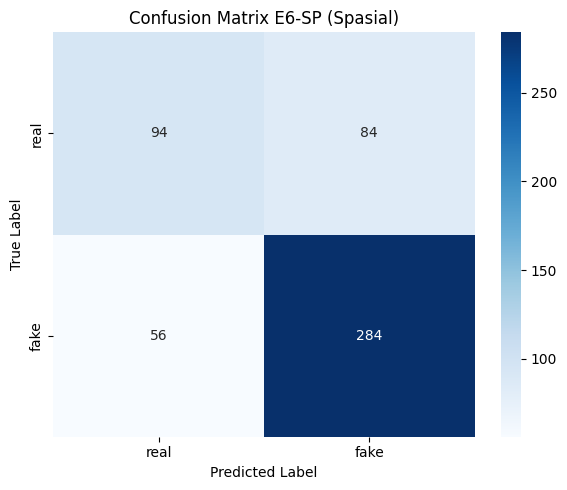

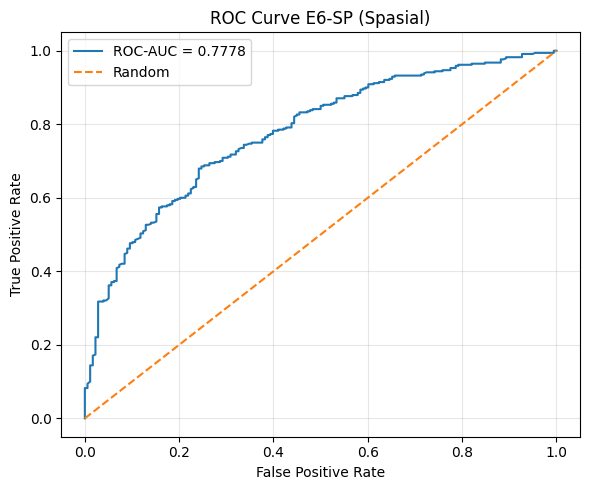


HASIL E6-SP
Accuracy        : 72.9730%
Precision macro : 69.9203%
Recall macro    : 68.1692%
F1 macro        : 68.7715%
ROC-AUC         : 77.7784%
Confusion Matrix [real, fake] x [real, fake]:
[[ 94  84]
 [ 56 284]]

RUN E6-ST - Spasiotemporal
Model kind                        : spatiotemporal_videomae
Source checkpoint                 : M6-ST
W&B artifact                      : E01_spatiotemporal_videomae_videomae-base-finetuned-ssv2_outputs:v10
Checkpoint file                   : /shared-docker/wandb_artifacts/E6_celebdfv2_zero_shot/E01_spatiotemporal_videomae_videomae-base-finetuned-ssv2_outputs_v10/best_E01_videomae.pt
Batch size                        : 32


Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at /shared-docker/celebdfv2_runtime/kaggle_models/videomae-base-finetuned-ssv2/videomae-base-finetuned-ssv2 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([174, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([174]) in the checkpoint and torch.Size([2]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Checkpoint loaded: /shared-docker/wandb_artifacts/E6_celebdfv2_zero_shot/E01_spatiotemporal_videomae_videomae-base-finetuned-ssv2_outputs_v10/best_E01_videomae.pt
Checkpoint experiment_code    : E01
Checkpoint selected_by        : val_accuracy
Checkpoint epoch              : 16
Checkpoint best_val_accuracy  : 0.9442733127975357
Checkpoint best_val_f1_macro  : 0.9410420267905182


Inference spatiotemporal_videomae:   0% 0/17 [00:00<?, ?it/s]

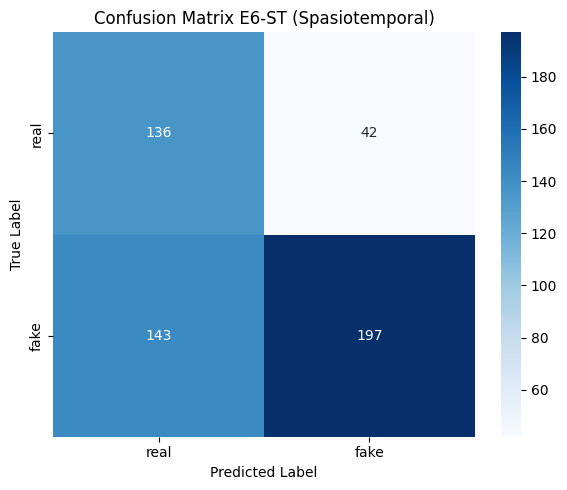

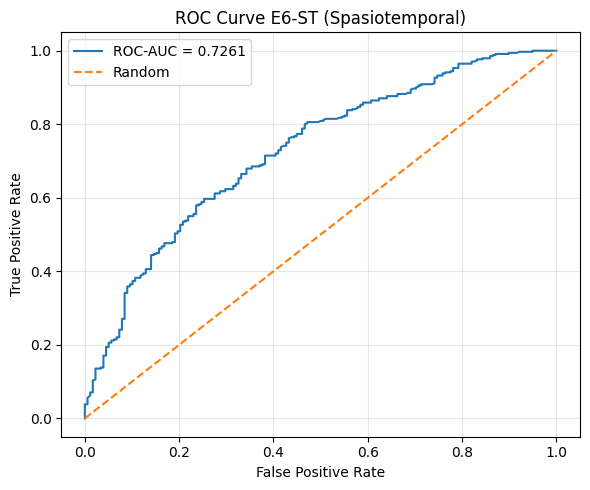


HASIL E6-ST
Accuracy        : 64.2857%
Precision macro : 65.5861%
Recall macro    : 67.1728%
F1 macro        : 63.7835%
ROC-AUC         : 72.6148%
Confusion Matrix [real, fake] x [real, fake]:
[[136  42]
 [143 197]]

RINGKASAN E6


,Kode,Model,Sumber Checkpoint,Dataset Uji,Acc,Prec,Rec,F1,AUC,test_loss,num_samples
0,E6-SP,Spasial,M6-SP,Celeb-DF v2,72.972973,69.920290,68.169200,68.771531,77.778420,1.124738,518
1,E6-ST,Spasiotemporal,M6-ST,Celeb-DF v2,64.285714,65.586149,67.172835,63.783479,72.614838,1.267882,518


Summary CSV : /shared-docker/experiments_celebdfv2/E6_cross_dataset_zero_shot/E6_celebdfv2_zero_shot_summary.csv
Summary JSON: /shared-docker/experiments_celebdfv2/E6_cross_dataset_zero_shot/E6_celebdfv2_zero_shot_summary.json


wandb: Adding directory to artifact (/shared-docker/experiments_celebdfv2/E6_cross_dataset_zero_shot/E6-SP)... Done. 0.0s


Output E6-SP berhasil dilog ke W&B.


test/accuracy,▁
test/f1_macro,▁
test/f1_weighted,▁
test/loss,▁
test/num_roc_thresholds,▁
test/precision_macro,▁
test/precision_weighted,▁
test/recall_macro,▁
test/recall_weighted,▁
test/roc_auc,▁
+1,...


wandb: Adding directory to artifact (/shared-docker/experiments_celebdfv2/E6_cross_dataset_zero_shot/E6-ST)... Done. 0.0s


Output E6-ST berhasil dilog ke W&B.


test/accuracy,▁
test/f1_macro,▁
test/f1_weighted,▁
test/loss,▁
test/num_roc_thresholds,▁
test/precision_macro,▁
test/precision_weighted,▁
test/recall_macro,▁
test/recall_weighted,▁
test/roc_auc,▁
+1,...


In [45]:

criterion = nn.CrossEntropyLoss()
all_summary_rows = []
all_output_infos = []

for run_cfg in E6_RUNS:
    print_section(f"RUN {run_cfg['report_code']} - {run_cfg['model_label']}")
    print_kv("Model kind", run_cfg["model_kind"])
    print_kv("Source checkpoint", run_cfg["source_checkpoint"])
    print_kv("W&B artifact", f"{run_cfg['artifact_name']}:{run_cfg['artifact_version']}")
    print_kv("Checkpoint file", run_cfg["checkpoint_path"])
    print_kv("Batch size", run_cfg["batch_size"])

    loader = make_test_loader(test_dataset, batch_size=int(run_cfg["batch_size"]))

    model = build_model(run_cfg["model_kind"], E6_INPUT_CFG)
    model, checkpoint_metadata, missing_keys, unexpected_keys = load_checkpoint_into_model(
        model=model,
        checkpoint_path=Path(run_cfg["checkpoint_path"]),
    )

    model = model.to(DEVICE)
    model.eval()

    result = run_inference(
        model=model,
        loader=loader,
        model_kind=run_cfg["model_kind"],
        criterion=criterion,
        device=DEVICE,
    )

    output_dir = build_output_dir(run_cfg)
    output_info = save_result_outputs(
        result=result,
        run_cfg=run_cfg,
        checkpoint_metadata=checkpoint_metadata,
        output_dir=output_dir,
    )
    all_output_infos.append(output_info)

    summary_row = {
        "Kode": run_cfg["report_code"],
        "Model": run_cfg["model_label"],
        "Sumber Checkpoint": run_cfg["source_checkpoint"],
        "Dataset Uji": "Celeb-DF v2",
        "Acc": percent_value(result["accuracy"]),
        "Prec": percent_value(result["precision_macro"]),
        "Rec": percent_value(result["recall_macro"]),
        "F1": percent_value(result["f1_macro"]),
        "AUC": percent_value(result.get("roc_auc", float("nan"))),
        "test_loss": float(result["loss"]),
        "num_samples": int(len(result["y_true"])),
    }
    all_summary_rows.append(summary_row)

    print("\nHASIL", run_cfg["report_code"])
    print(f"Accuracy        : {summary_row['Acc']:.4f}%")
    print(f"Precision macro : {summary_row['Prec']:.4f}%")
    print(f"Recall macro    : {summary_row['Rec']:.4f}%")
    print(f"F1 macro        : {summary_row['F1']:.4f}%")
    print(f"ROC-AUC         : {summary_row['AUC']:.4f}%")
    print("Confusion Matrix [real, fake] x [real, fake]:")
    print(result["cm"])

    del model, result, loader
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

summary_df = pd.DataFrame(all_summary_rows)

summary_csv_path = OUTPUT_ROOT / "E6_celebdfv2_zero_shot_summary.csv"
summary_json_path = OUTPUT_ROOT / "E6_celebdfv2_zero_shot_summary.json"

summary_df.to_csv(summary_csv_path, index=False)
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(all_summary_rows, f, indent=2)

print_section("RINGKASAN E6")
display(summary_df)

print("Summary CSV :", summary_csv_path)
print("Summary JSON:", summary_json_path)

log_e6_outputs_to_wandb(summary_df, OUTPUT_ROOT)


## 14. Format Tabel untuk Laporan

In [46]:

report_table = summary_df[["Kode", "Model", "Sumber Checkpoint", "Dataset Uji", "Acc", "Prec", "Rec", "F1", "AUC"]].copy()

for col in ["Acc", "Prec", "Rec", "F1", "AUC"]:
    report_table[col] = report_table[col].map(lambda x: f"{x:.1f}%" if pd.notna(x) else "-")

display(report_table)

print("Tabel 4.18 Hasil Evaluasi Lintas-Dataset pada Dataset Celeb-DF v2")
print(report_table.to_markdown(index=False))


,Kode,Model,Sumber Checkpoint,Dataset Uji,Acc,Prec,Rec,F1,AUC
0,E6-SP,Spasial,M6-SP,Celeb-DF v2,73.0%,69.9%,68.2%,68.8%,77.8%
1,E6-ST,Spasiotemporal,M6-ST,Celeb-DF v2,64.3%,65.6%,67.2%,63.8%,72.6%


Tabel 4.18 Hasil Evaluasi Lintas-Dataset pada Dataset Celeb-DF v2
| Kode   | Model          | Sumber Checkpoint   | Dataset Uji   | Acc   | Prec   | Rec   | F1    | AUC   |
|:-------|:---------------|:--------------------|:--------------|:------|:-------|:------|:------|:------|
| E6-SP  | Spasial        | M6-SP               | Celeb-DF v2   | 73.0% | 69.9%  | 68.2% | 68.8% | 77.8% |
| E6-ST  | Spasiotemporal | M6-ST               | Celeb-DF v2   | 64.3% | 65.6%  | 67.2% | 63.8% | 72.6% |
